In [1]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os
import cv2 as cv2

In [2]:
path_to_data = '/kaggle/input/mango-leaf-disease-detection-raw-augmented-data'

In [3]:
data = []
labels = []

img_size = (224, 224)
for folder in os.listdir(path_to_data):
    print(folder)
    for file in os.listdir(os.path.join(path_to_data, folder)):
        img_path = os.path.join(path_to_data, folder, file)
        img = cv2.imread(img_path, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, img_size)
        data.append(img)
        labels.append(folder)

# Convert to NumPy arrays if needed
data = np.array(data, dtype=np.float32)
labels = np.array(labels)

gall_midge
anthracnose
die_black
powdery_mildew
healthy


In [4]:
# Normalization
data = data/255.0

In [5]:
data[0]

array([[[0.6039216 , 0.59607846, 0.57254905],
        [0.60784316, 0.6       , 0.5764706 ],
        [0.60784316, 0.6       , 0.5764706 ],
        ...,
        [0.6392157 , 0.62352943, 0.61960787],
        [0.63529414, 0.61960787, 0.61960787],
        [0.6313726 , 0.61960787, 0.6117647 ]],

       [[0.6039216 , 0.59607846, 0.57254905],
        [0.60784316, 0.6       , 0.5764706 ],
        [0.60784316, 0.6       , 0.5764706 ],
        ...,
        [0.6392157 , 0.627451  , 0.62352943],
        [0.6392157 , 0.62352943, 0.61960787],
        [0.63529414, 0.61960787, 0.61960787]],

       [[0.6039216 , 0.59607846, 0.57254905],
        [0.60784316, 0.6       , 0.5764706 ],
        [0.60784316, 0.6       , 0.5764706 ],
        ...,
        [0.6392157 , 0.62352943, 0.61960787],
        [0.6392157 , 0.62352943, 0.61960787],
        [0.6392157 , 0.62352943, 0.61960787]],

       ...,

       [[0.7137255 , 0.69803923, 0.68235296],
        [0.7137255 , 0.69803923, 0.68235296],
        [0.7176471 , 0

In [6]:
from sklearn.preprocessing import LabelEncoder

# Initialize LabelEncoder
label_encoder = LabelEncoder()

# Fit and transform labels
encoded_labels = label_encoder.fit_transform(labels)

# Create mapping of original labels to encoded values
label_mapping = dict(zip(label_encoder.classes_, range(len(label_encoder.classes_))))

# Print the mapping
print("Label Mapping:")
for original, encoded in label_mapping.items():
    print(f"{original} -> {encoded}")

# Print the transformed labels
print("\nEncoded Labels:")
print(encoded_labels)

Label Mapping:
anthracnose -> 0
die_black -> 1
gall_midge -> 2
healthy -> 3
powdery_mildew -> 4

Encoded Labels:
[2 2 2 ... 3 3 3]


In [7]:
np.unique(encoded_labels)

array([0, 1, 2, 3, 4])

In [8]:
data[0]

array([[[0.6039216 , 0.59607846, 0.57254905],
        [0.6039216 , 0.59607846, 0.57254905],
        [0.60784316, 0.6       , 0.5764706 ],
        ...,
        [0.63529414, 0.61960787, 0.61960787],
        [0.63529414, 0.61960787, 0.61960787],
        [0.6313726 , 0.6156863 , 0.60784316]],

       [[0.6039216 , 0.59607846, 0.57254905],
        [0.6039216 , 0.59607846, 0.57254905],
        [0.60784316, 0.6       , 0.5764706 ],
        ...,
        [0.6392157 , 0.62352943, 0.61960787],
        [0.63529414, 0.61960787, 0.61960787],
        [0.63529414, 0.61960787, 0.6156863 ]],

       [[0.6039216 , 0.59607846, 0.57254905],
        [0.6039216 , 0.59607846, 0.57254905],
        [0.60784316, 0.6       , 0.5764706 ],
        ...,
        [0.6392157 , 0.62352943, 0.61960787],
        [0.63529414, 0.61960787, 0.61960787],
        [0.63529414, 0.61960787, 0.61960787]],

       ...,

       [[0.7137255 , 0.69411767, 0.68235296],
        [0.7137255 , 0.69803923, 0.68235296],
        [0.7137255 , 0

In [ ]:
import random
import matplotlib.pyplot as plt
import numpy as np

# Define label mapping
label_mapping = {
    0: "Anthracnose",
    1: "Die Black",
    2: "Gall Midge",
    3: "Healthy",
    4: "Powdery Mildew"
}

# Sample 5 random indices from each class
r_b = random.sample(list(np.where(encoded_labels == 0)[0]), 5)
r_f = random.sample(list(np.where(encoded_labels == 1)[0]), 5)
r_g = random.sample(list(np.where(encoded_labels == 2)[0]), 5)
r_m = random.sample(list(np.where(encoded_labels == 3)[0]), 5)
r_se = random.sample(list(np.where(encoded_labels == 4)[0]), 5)

# Combine the selected indices and reshape into a 5x5 grid
plots = np.array(r_b + r_f + r_g + r_m + r_se).reshape(5, 5)

# Create subplots
fig, ax = plt.subplots(5, 5, figsize=(10, 10))
fig.subplots_adjust(hspace=0.5, wspace=0.5)  # Adjust spacing

# Plot images with corresponding class names
for i in range(5):
    for j in range(5):
        idx = plots[i, j]
        ax[i, j].imshow(data[idx])  # RGB images, so no cmap='gray'
        ax[i, j].set_title(f"{label_mapping[encoded_labels[idx]]}", fontsize=8)
        ax[i, j].axis('off')

plt.show()


In [ ]:
# Flatten each color channel
red_values = data[:, :, :, 0].ravel()   # Red channel
green_values = data[:, :, :, 1].ravel() # Green channel
blue_values = data[:, :, :, 2].ravel()  # Blue channel

# Plot histograms
plt.figure(figsize=(12, 6))
plt.hist(red_values, bins=256, color='red', alpha=0.6, label="Red Channel")
plt.hist(green_values, bins=256, color='green', alpha=0.6, label="Green Channel")
plt.hist(blue_values, bins=256, color='blue', alpha=0.6, label="Blue Channel")

# Labels and Title
plt.xlabel("Pixel Intensity (0-255)")
plt.ylabel("Frequency")
plt.title("RGB Histogram of All Images")
plt.legend()
plt.show()

In [ ]:
# Count occurrences of each label
unique_labels, label_counts = np.unique(encoded_labels, return_counts=True)

# Create a bar plot
plt.figure(figsize=(8, 5))
ax = sns.barplot(x=unique_labels, y=label_counts, palette="viridis")

# Add count labels on top of each bar
for i, count in enumerate(label_counts):
    ax.text(i, count + 0.5, str(count), ha='center', fontsize=12, fontweight='bold')

# Labels and title
plt.xlabel("Labels")
plt.ylabel("Count")
plt.title("Distribution of Encoded Labels")
plt.show()

In [7]:
from sklearn.model_selection import train_test_split
# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(data, encoded_labels, test_size=0.2, random_state=42, shuffle=True)

# Ensure correct shape for RGB images
X_train = X_train.reshape(-1, 224, 224, 3)
X_test = X_test.reshape(-1, 224, 224, 3)

# Define number of classes
num_classes = len(np.unique(encoded_labels))

print("Number of classes:", num_classes)
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

Number of classes: 5
X_train shape: (6984, 224, 224, 3)
X_test shape: (1746, 224, 224, 3)


In [10]:
print("Unique classes in y_train:", np.unique(y_train))
print("Unique classes in y_test:", np.unique(y_test))
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)


Unique classes in y_train: [0 1 2 3 4]
Unique classes in y_test: [0 1 2 3 4]
y_train shape: (6984,)
y_test shape: (1746,)


# GoogleNet(Inception V-3)

In [8]:
from tensorflow.keras.layers import Input, Conv2D, BatchNormalization, Activation, MaxPooling2D, AveragePooling2D, Add, Flatten,GlobalAveragePooling2D, Dense,ZeroPadding2D, concatenate
from tensorflow.keras.models import Model
from tensorflow.keras.initializers import glorot_uniform
import tensorflow as tf

In [9]:
# Define inception module function
def inception_module(x, f1, f2, f3):
    conv1 = Conv2D(f1, (1, 1), padding='same', activation='relu')(x)
    conv3 = Conv2D(f2, (3, 3), padding='same', activation='relu')(x)
    conv5 = Conv2D(f3, (5, 5), padding='same', activation='relu')(x)
    pool = MaxPooling2D((3, 3), strides=(1, 1), padding='same')(x)
    out = concatenate([conv1, conv3, conv5, pool], axis=channel_axis)
    return out
# Define conv2d_bn function
def conv2d_bn(x, filters, num_row, num_col, padding='same', strides=(1, 1)):
    x = Conv2D(filters, (num_row, num_col), strides=strides, padding=padding)(x)
    x = BatchNormalization(axis=channel_axis, scale=False)(x)
    x = Activation('relu')(x)
    return x
# Define inception and reduction blocks
def inc_block_a(x):
    branch1x1 = conv2d_bn(x, 64, 1, 1)

    branch5x5 = conv2d_bn(x, 48, 1, 1)
    branch5x5 = conv2d_bn(branch5x5, 64, 5, 5)

    branch3x3dbl = conv2d_bn(x, 64, 1, 1)
    branch3x3dbl = conv2d_bn(branch3x3dbl, 96, 3, 3)
    branch3x3dbl = conv2d_bn(branch3x3dbl, 96, 3, 3)

    branch_pool = AveragePooling2D((3, 3), strides=(1, 1), padding='same')(x)
    branch_pool = conv2d_bn(branch_pool, 32, 1, 1)
    x = concatenate([branch1x1, branch5x5, branch3x3dbl, branch_pool], axis=channel_axis)
    return x
def reduction_block_a(x):
    branch3x3 = conv2d_bn(x, 384, 3, 3, strides=(2, 2), padding='valid')

    branch3x3dbl = conv2d_bn(x, 64, 1, 1)
    branch3x3dbl = conv2d_bn(branch3x3dbl, 96, 3, 3)
    branch3x3dbl = conv2d_bn(branch3x3dbl, 96, 3, 3, strides=(2, 2), padding='valid')

    branch_pool = MaxPooling2D((3, 3), strides=(2, 2))(x)
    x = concatenate([branch3x3, branch3x3dbl, branch_pool], axis=channel_axis)
    return x


def inc_block_b(x):
    branch1x1 = conv2d_bn(x, 192, 1, 1)

    branch7x7 = conv2d_bn(x, 128, 1, 1)
    branch7x7 = conv2d_bn(branch7x7, 128, 1, 7)
    branch7x7 = conv2d_bn(branch7x7, 192, 7, 1)

    branch7x7dbl = conv2d_bn(x, 128, 1, 1)
    branch7x7dbl = conv2d_bn(branch7x7dbl, 128, 7, 1)
    branch7x7dbl = conv2d_bn(branch7x7dbl, 128, 1, 7)
    branch7x7dbl = conv2d_bn(branch7x7dbl, 128, 7, 1)
    branch7x7dbl = conv2d_bn(branch7x7dbl, 192, 1, 7)

    branch_pool = AveragePooling2D((3, 3), strides=(1, 1), padding='same')(x)
    branch_pool = conv2d_bn(branch_pool, 192, 1, 1)
    x = concatenate([branch1x1, branch7x7, branch7x7dbl, branch_pool], axis=channel_axis)
    return x
def reduction_block_b(x):
    branch3x3 = conv2d_bn(x, 192, 1, 1)
    branch3x3 = conv2d_bn(branch3x3, 320, 3, 3, strides=(2, 2), padding='valid')

    branch7x7x3 = conv2d_bn(x, 192, 1, 1)
    branch7x7x3 = conv2d_bn(branch7x7x3, 192, 1, 7)
    branch7x7x3 = conv2d_bn(branch7x7x3, 192, 7, 1)
    branch7x7x3 = conv2d_bn(branch7x7x3, 192, 3, 3, strides=(2, 2), padding='valid')

    branch_pool = MaxPooling2D((3, 3), strides=(2, 2))(x)
    x = concatenate([branch3x3, branch7x7x3, branch_pool], axis=channel_axis)
    return x

def inc_block_c(x):
    branch1x1 = conv2d_bn(x, 320, 1, 1)

    branch3x3 = conv2d_bn(x, 384, 1, 1)
    branch3x3_1 = conv2d_bn(branch3x3, 384, 1, 3)
    branch3x3_2 = conv2d_bn(branch3x3, 384, 3, 1)
    branch3x3 = concatenate([branch3x3_1, branch3x3_2], axis=channel_axis)

    branch3x3dbl = conv2d_bn(x, 448, 1, 1)
    branch3x3dbl = conv2d_bn(branch3x3dbl, 384, 3, 3)
    branch3x3dbl_1 = conv2d_bn(branch3x3dbl, 384, 1, 3)
    branch3x3dbl_2 = conv2d_bn(branch3x3dbl, 384, 3, 1)
    branch3x3dbl = concatenate([branch3x3dbl_1, branch3x3dbl_2], axis=channel_axis)

    branch_pool = AveragePooling2D((3, 3), strides=(1, 1), padding='same')(x)
    branch_pool = conv2d_bn(branch_pool, 192, 1, 1)
    x = concatenate([branch1x1, branch3x3, branch3x3dbl, branch_pool], axis=channel_axis)
    return x


img_input = Input(shape=(224, 224, 3))  # Grayscale images
channel_axis = -1 
x = conv2d_bn(img_input, 32, 3, 3, strides=(2, 2), padding='valid')  # 149 x 149 x 32
x = conv2d_bn(x, 32, 3, 3, padding='valid')  # 147 x 147 x 32
x = conv2d_bn(x, 64, 3, 3)  # 147 x 147 x 64

x = MaxPooling2D((3, 3), strides=(2, 2))(x)  # 73 x 73 x 64
x = conv2d_bn(x, 80, 1, 1, padding='valid')  # 73 x 73 x 80
x = conv2d_bn(x, 192, 3, 3, padding='valid')  # 71 x 71 x 192
x = MaxPooling2D((3, 3), strides=(2, 2))(x)  # 35 x 35 x 192

x = inc_block_a(x)  # 35 x 35 x 256
x = inc_block_a(x)  # 35 x 35 x 256
x = inc_block_a(x)  # 35 x 35 x 256

x = reduction_block_a(x)  # 17 x 17 x 736

x = inc_block_b(x)  # 17 x 17 x 768
x = inc_block_b(x)  # 17 x 17 x 768
x = inc_block_b(x)  # 17 x 17 x 768
x = inc_block_b(x)  # 17 x 17 x 768

x = reduction_block_b(x)  # 8 x 8 x 1280

x = inc_block_c(x)  # 8 x 8 x 2048
x = inc_block_c(x)  # 8 x 8 x 2048

x = GlobalAveragePooling2D(name='avg_pool')(x)  # shape=(None, 2048)


classes = 5  
x = Dense(classes, activation='softmax', name='predictions')(x)  # shape=(None, 1000)
# Build the model

# Create model
model5 = Model(img_input, x, name='inception_v3')

In [18]:
model5.summary()

Model: "inception_v3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2             │ (None, 299, 299, 1)    │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_106 (Conv2D)       │ (None, 149, 149, 32)   │            320 │ input_layer_2[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_106   │ (None, 149, 149, 32)   │             96 │ conv2d_106[0][0]       │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation_106            │ (None, 149, 149, 32)   │              0 │ batch_normalization_1… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_107 (Conv2D)       │ (None, 147, 147, 32)   │          9,248 │ activation_106[0][0]   │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_107   │ (None, 147, 147, 32)   │             96 │ conv2d_107[0][0]       │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation_107            │ (None, 147, 147, 32)   │              0 │ batch_normalization_1… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_108 (Conv2D)       │ (None, 147, 147, 64)   │         18,496 │ activation_107[0][0]   │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_108   │ (None, 147, 147, 64)   │            192 │ conv2d_108[0][0]       │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation_108            │ (None, 147, 147, 64)   │              0 │ batch_normalization_1… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_6           │ (None, 73, 73, 64)     │              0 │ activation_108[0][0]   │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_109 (Conv2D)       │ (None, 73, 73, 80)     │          5,200 │ max_pooling2d_6[0][0]  │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_109   │ (None, 73, 73, 80)     │            240 │ conv2d_109[0][0]       │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation_109            │ (None, 73, 73, 80)     │              0 │ batch_normalization_1… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_110 (Conv2D)  

 Total params: 20,038,949 (76.44 MB)

 Trainable params: 20,006,181 (76.32 MB)

 Non-trainable params: 32,768 (128.00 KB)

In [10]:
model5.compile(optimizer=tf.keras.optimizers.SGD(learning_rate=0.001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [11]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

# Define the path where the model with the best parameters will be saved
checkpoint_path = "best_model.keras"

# Create a callback that saves the model with the best validation accuracy
checkpoint_callback = ModelCheckpoint(
    filepath=checkpoint_path,
    monitor='val_accuracy',  # Monitor validation accuracy
    save_best_only=True,
    save_weights_only=False,
    mode='max',  # Save when val_accuracy is maximized
    verbose=1
)

# Create an EarlyStopping callback with patience=5
early_stopping_callback = EarlyStopping(
    monitor='val_accuracy',  # Monitor validation accuracy
    patience=10,  # Stop training if no improvement after 10 epochs
    mode='max',  # Check for maximization of val_accuracy
    verbose=1,
    restore_best_weights=True  # Restore model weights from the epoch with the best validation accuracy
)

# Train the model with the checkpoint and early stopping callbacks
history5 = model5.fit(X_train, y_train,
                    validation_split=0.2,
                    epochs=50,
                    batch_size=32,
                    callbacks=[checkpoint_callback, early_stopping_callback])


Epoch 1/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 380ms/step - accuracy: 0.4290 - loss: 1.4334
Epoch 1: val_accuracy improved from -inf to 0.20830, saving model to best_model.keras
175/175 ━━━━━━━━━━━━━━━━━━━━ 135s 471ms/step - accuracy: 0.4297 - loss: 1.4323 - val_accuracy: 0.2083 - val_loss: 1.7030
Epoch 2/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 213ms/step - accuracy: 0.7510 - loss: 0.8354
Epoch 2: val_accuracy improved from 0.20830 to 0.21188, saving model to best_model.keras
175/175 ━━━━━━━━━━━━━━━━━━━━ 41s 235ms/step - accuracy: 0.7511 - loss: 0.8348 - val_accuracy: 0.2119 - val_loss: 2.0095
Epoch 3/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 219ms/step - accuracy: 0.8499 - loss: 0.5206
Epoch 3: val_accuracy improved from 0.21188 to 0.63923, saving model to best_model.keras
175/175 ━━━━━━━━━━━━━━━━━━━━ 42s 240ms/step - accuracy: 0.8499 - loss: 0.5204 - val_accuracy: 0.6392 - val_loss: 0.8588
Epoch 4/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 215ms/step - accuracy: 0.8874 - loss: 0.3647
Epoch 4: val_accuracy i

55/55 ━━━━━━━━━━━━━━━━━━━━ 14s 184ms/step
Test Accuracy: 0.9954
Test Precision: 0.9951
Test Recall (Sensitivity): 0.9959
Test Specificity: 0.9951
Test F1 Score: 0.9954

Classification Report:
                 precision    recall  f1-score   support

   anthracnose       1.00      1.00      1.00       321
     die_black       1.00      1.00      1.00       434
    gall_midge       1.00      0.98      0.99       399
       healthy       0.99      1.00      0.99       338
powdery_mildew       0.99      1.00      1.00       254

      accuracy                           1.00      1746
     macro avg       1.00      1.00      1.00      1746
  weighted avg       1.00      1.00      1.00      1746



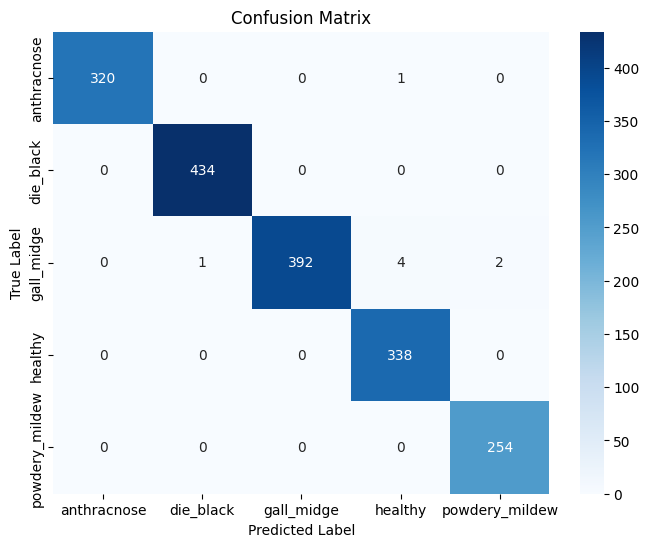

In [12]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Labels
class_labels = ['anthracnose', 'die_black', 'gall_midge', 'healthy', 'powdery_mildew']

# Predict class probabilities
y_pred_probs = model5.predict(X_test)

# Convert probabilities to class labels
y_pred = np.argmax(y_pred_probs, axis=1)

# Ensure y_test is in correct format
if len(y_test.shape) > 1 and y_test.shape[1] > 1:  # If one-hot encoded
    y_true = np.argmax(y_test, axis=1)  # Convert to class labels
else:  
    y_true = y_test  # Already in label format

# Compute accuracy, precision, recall, and F1 score
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='macro')
recall = recall_score(y_true, y_pred, average='macro')
f1 = f1_score(y_true, y_pred, average='macro')

# Compute Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

# Compute Sensitivity and Specificity for Multi-Class
class_sensitivity = np.diag(cm) / np.sum(cm, axis=1)  # Sensitivity per class
class_specificity = np.diag(cm) / np.sum(cm, axis=0)  # Specificity per class
sensitivity = np.mean(class_sensitivity)  # Mean Sensitivity
specificity = np.mean(class_specificity)  # Mean Specificity

# Print Evaluation Metrics
print(f"Test Accuracy: {accuracy:.4f}")
print(f"Test Precision: {precision:.4f}")
print(f"Test Recall (Sensitivity): {sensitivity:.4f}")
print(f"Test Specificity: {specificity:.4f}")
print(f"Test F1 Score: {f1:.4f}")
print("\nClassification Report:\n", classification_report(y_true, y_pred, target_names=class_labels))

# Plot Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()


In [13]:
model5.save('/kaggle/working/Inception-V3.keras')